In [2]:
import pandas as pd

results = pd.read_csv("predictions.csv")

results.head()

,Actual,Predicted
0,28.122222,16.670722
1,10.000000,4.409222
2,14.400000,9.889500
3,1.016667,4.244389
4,-0.122222,-0.659500


In [3]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    results["Actual"],
    results["Predicted"]
)

print("Monitoring MAE:", mae)

Monitoring MAE: 4.200896673511155


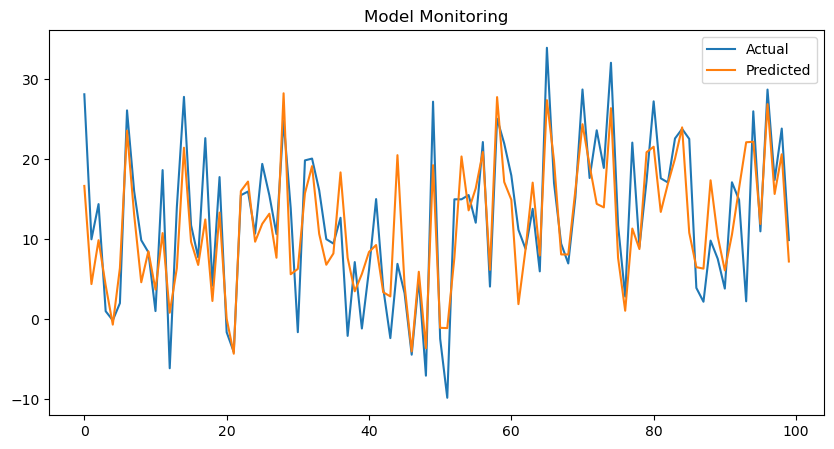

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results["Actual"].head(100), label="Actual")
plt.plot(results["Predicted"].head(100), label="Predicted")
plt.legend()
plt.title("Model Monitoring")
plt.show()

In [5]:
results["Error"] = abs(
    results["Actual"] - results["Predicted"]
)

results["Error"].describe()

count    19291.000000
mean         4.200897
std          3.483652
min          0.000611
25%          1.511611
50%          3.364500
75%          6.007083
max         40.077444
Name: Error, dtype: float64

In [6]:
drift_threshold = 5

drift_count = (
    results["Error"] > drift_threshold
).sum()

print("Drift Records:", drift_count)

Drift Records: 6475
